In [1]:
from pathlib import Path
import shutil
import pandas as pd
import os
from tqdm import tqdm
from PIL import Image as PILImage
import re

WORK = Path(os.environ.get("WORK", Path.cwd()))
PROJECT_ROOT = WORK / "color-concept-entanglement"

DATA = PROJECT_ROOT / "data"
IMAGE_BASE_COLOR = DATA / "color_images"
IMAGE_BASE_SHAPES = DATA / "shapes" / "shape_colored"

EXPORT_ROOT = PROJECT_ROOT / "hf_dataset_export"
EXPORT_ROOT.mkdir(exist_ok=True)

EXPORT_IMAGES = EXPORT_ROOT / "images"

## Dataset used for VLM and human evaluation

In [2]:
# Load the datasets that where also used in the human evaluation
prior_df = pd.read_csv(DATA / "prolific_stimuli" / f"stimulus_table_image_priors_prolific.csv")
counterfact_df = pd.read_csv(DATA / "prolific_stimuli" / f"stimulus_table_counterfact_prolific.csv")
shape_df = pd.read_csv(DATA / "prolific_stimuli" / f"stimulus_table_shapes_prolific.csv")

display(prior_df.head(), prior_df.shape, counterfact_df.head(), counterfact_df.shape, shape_df.head(), shape_df.shape)

,image_path,object,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,variant_label,mode
0,color_images/gpt-4o/image_priors/cheese_1_78f6...,cheese,correct_prior,yellow,white,BG,80,BG 80% (seq),seq
1,color_images/gpt-4o/image_priors/espresso_make...,espresso maker,correct_prior,red,red,FG,5,FG 5% (seq),seq
2,color_images/gpt-4o/image_priors/tile_roof_2_f...,tile roof,correct_prior,red,red,FG,100,FG 100% (seq),seq
3,color_images/gpt-4o/image_priors/cloud_3_29898...,cloud,correct_prior,grey,grey,FG,55,FG 55% (seq),seq
4,color_images/gpt-4o/image_priors/frilled_lizar...,frilled lizard,correct_prior,brown,brown,FG,100,FG 100% (seq),seq


(1260, 9)

,image_path,object,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,variant_label,mode
0,color_images/gpt-4o/counterfact/rose_3_6471302...,rose,counterfact,blue,blue,FG,100,FG 100% (seq),seq
1,color_images/gpt-4o/counterfact/Sealyham_terri...,sealyham terrier,counterfact,purple,purple,FG,60,FG 60% (seq),seq
2,color_images/gpt-4o/counterfact/iguana_2_a2663...,iguana,counterfact,orange,orange,FG,10,FG 10% (seq),seq
3,color_images/gpt-4o/counterfact/hartebeest_3_5...,hartebeest,counterfact,red,red,FG,55,FG 55% (seq),seq
4,color_images/gpt-4o/counterfact/mouse_2_cf4ddb...,mouse,counterfact,red,red,FG,20,FG 20% (seq),seq


(412, 9)

,image_path,object,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,variant_label,mode
0,shapes/shape_colored/hexagon_v3_yellow/FG_060_...,hexagon,shape,yellow,yellow,FG,60,FG 60% (seq),seq
1,shapes/shape_colored/pentagon_v0_purple/FG_055...,pentagon,shape,purple,purple,FG,55,FG 55% (seq),seq
2,shapes/shape_colored/square_v3_blue/FG_005_seq...,square,shape,blue,blue,FG,5,FG 5% (seq),seq
3,shapes/shape_colored/triangle_v0_brown/FG_050_...,triangle,shape,brown,brown,FG,50,FG 50% (seq),seq
4,shapes/shape_colored/pentagon_v2_orange/FG_090...,pentagon,shape,orange,orange,FG,90,FG 90% (seq),seq


(1331, 9)

In [1]:
shape_df[(shape_df.object == "triangle") & (shape_df["variant_region"] == "BG")]["percent_colored"].value_counts()

NameError: name 'shape_df' is not defined

In [ ]:
shape_df[shape_df["variant_region"] == "FG"]["percent_colored"].value_counts()

percent_colored
5      94
70     93
0      93
90     92
50     91
40     90
55     90
100    89
60     88
10     88
20     86
30     85
80     84
Name: count, dtype: int64

In [7]:
COLOR_BASE = DATA / "color_images"
SHAPE_BASE = DATA / "shapes" / "shape_colored"


def clean_stimulus_name(folder_name):
    # remove hash and resized parts
    folder_name = re.sub(r"_\d+_[a-f0-9]+_resized", "", folder_name)
    folder_name = folder_name.replace("_resized", "")
    return folder_name


def clean_image_name(stimulus_name, filename):
    # remove _seq
    filename = filename.replace("_seq", "")
    return f"{stimulus_name}_{filename}"


def resolve_original_path(p):
    p = Path(p)

    if p.is_absolute():
        return p

    if str(p).startswith("color_images"):
        return DATA / p
    elif str(p).startswith("shapes"):
        return DATA / p
    else:
        raise ValueError(f"Cannot resolve original path: {p}")


def make_relative_export_path(original_path, subfolder):
    original_path = Path(original_path)

    stimulus_dir = original_path.parent.name
    filename = original_path.name

    return Path("images") / subfolder / stimulus_dir / filename



def export_dataset(df, filename, subfolder):
    df_export = df.copy()

    original_paths = []
    export_paths = []

    for p in df_export["image_path"]:
        orig = resolve_original_path(p)

        original_folder = orig.parent.name
        clean_folder = clean_stimulus_name(original_folder)

        original_filename = orig.name
        clean_filename = clean_image_name(clean_folder, original_filename)

        exp = Path("images") / subfolder / clean_folder / clean_filename

        original_paths.append(orig)
        export_paths.append(exp)


    df_export["image_path"] = [str(p) for p in export_paths]

    unique_pairs = dict(zip(export_paths, original_paths))

    for rel_path, orig_path in tqdm(unique_pairs.items(),
                                    desc=f"Copying images for {filename}"):

        destination = EXPORT_ROOT / rel_path
        destination.parent.mkdir(parents=True, exist_ok=True)

        if not destination.exists():
            shutil.copy2(orig_path, destination)

    df_export.to_csv(EXPORT_ROOT / filename, index=False)

    print(f"{filename}: copied {len(unique_pairs)} images")

    return df_export

In [ ]:
prior_export = export_dataset(prior_df, subfolder="color_priors", filename="color_priors.csv")

Copying images for color_priors_fractions.csv:   0%|          | 0/1260 [00:00<?, ?it/s]

Copying images for color_priors_fractions.csv: 100%|██████████| 1260/1260 [00:02<00:00, 589.11it/s]

color_priors_fractions.csv: copied 1260 images


In [ ]:
counterfact_export = export_dataset(counterfact_df, subfolder="counterfact", filename="counterfact.csv")

Copying images for counterfact_fractions.csv: 100%|██████████| 412/412 [00:00<00:00, 3225.27it/s]

counterfact_fractions.csv: copied 412 images


In [ ]:
shape_export = export_dataset(shape_df, subfolder="shapes", filename="shapes.csv")

Copying images for shapes_fractions.csv: 100%|██████████| 1331/1331 [00:02<00:00, 464.69it/s]

shapes_fractions.csv: copied 1331 images


In [ ]:
def validate_export(df_export, split_name):
    
    print(f"\n Validating split: {split_name}")
    
    total_rows = len(df_export)
    unique_paths = df_export["image_path"].unique()
    
    print(f"Total rows: {total_rows}")
    print(f"Unique image paths: {len(unique_paths)}")
    
    missing_files = []
    wrong_size = []
    
    for rel_path in tqdm(unique_paths, desc=f"Checking images ({split_name})"):
        
        full_path = EXPORT_ROOT / rel_path
        
        # Check file exists
        if not full_path.exists():
            missing_files.append(rel_path)
            continue
        
        # Check image size
        try:
            with PILImage.open(full_path) as img:
                if img.size != (512, 512):
                    wrong_size.append((rel_path, img.size))
        except Exception as e:
            print(f"Could not open {rel_path}: {e}")
            missing_files.append(rel_path)
    
    # Report results
    if not missing_files:
        print("All image files exist.")
    else:
        print(f"Missing files: {len(missing_files)}")
        print(missing_files[:5])
    
    if not wrong_size:
        print("All images are 512x512.")
    else:
        print(f"Images with wrong size: {len(wrong_size)}")
        print(wrong_size[:5])
    
    print("Validation complete.\n")


In [ ]:
validate_export(prior_export, "color_priors")
validate_export(counterfact_export, "counterfact")
validate_export(shape_export, "shapes")


 Validating split: color_priors
Total rows: 1260
Unique image paths: 1260


Checking images (color_priors): 100%|██████████| 1260/1260 [00:00<00:00, 2062.97it/s]


All image files exist.
All images are 512x512.
Validation complete.


 Validating split: counterfact
Total rows: 412
Unique image paths: 412


Checking images (counterfact): 100%|██████████| 412/412 [00:00<00:00, 2768.11it/s]


All image files exist.
All images are 512x512.
Validation complete.


 Validating split: shapes
Total rows: 1331
Unique image paths: 1331


Checking images (shapes): 100%|██████████| 1331/1331 [00:00<00:00, 2943.42it/s]

All image files exist.
All images are 512x512.
Validation complete.



## Full Dataset

In [5]:
# Load the datasets that where also used in the human evaluation
full_prior_df = pd.read_csv(DATA / "prolific_stimuli" / f"stimulus_table_image_priors.csv")
full_counterfact_df = pd.read_csv(DATA / "prolific_stimuli" / f"stimulus_table_counterfact.csv")
full_shape_df = pd.read_csv(DATA / "prolific_stimuli" / f"stimulus_table_shapes.csv")

display(full_prior_df.head(), full_prior_df.shape, full_counterfact_df.head(), full_counterfact_df.shape, full_shape_df.head(), full_shape_df.shape)

,object,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,mode,variant_label,image_path
0,Band Aid,correct_prior,pink,white,BG,0,seq,BG 0% (seq),color_images/gpt-4o/image_priors/Band_Aid_1_e7...
1,Band Aid,correct_prior,pink,white,BG,5,seq,BG 5% (seq),color_images/gpt-4o/image_priors/Band_Aid_1_e7...
2,Band Aid,correct_prior,pink,white,BG,10,seq,BG 10% (seq),color_images/gpt-4o/image_priors/Band_Aid_1_e7...
3,Band Aid,correct_prior,pink,white,BG,20,seq,BG 20% (seq),color_images/gpt-4o/image_priors/Band_Aid_1_e7...
4,Band Aid,correct_prior,pink,white,BG,30,seq,BG 30% (seq),color_images/gpt-4o/image_priors/Band_Aid_1_e7...


(5174, 9)

,object,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,mode,variant_label,image_path
0,Band Aid,counterfact,purple,white,BG,0,seq,BG 0% (seq),color_images/gpt-4o/counterfact/Band_Aid_1_e73...
1,Band Aid,counterfact,purple,white,BG,5,seq,BG 5% (seq),color_images/gpt-4o/counterfact/Band_Aid_1_e73...
2,Band Aid,counterfact,purple,white,BG,10,seq,BG 10% (seq),color_images/gpt-4o/counterfact/Band_Aid_1_e73...
3,Band Aid,counterfact,purple,white,BG,20,seq,BG 20% (seq),color_images/gpt-4o/counterfact/Band_Aid_1_e73...
4,Band Aid,counterfact,purple,white,BG,30,seq,BG 30% (seq),color_images/gpt-4o/counterfact/Band_Aid_1_e73...


(5590, 9)

,object,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,mode,variant_label,image_path
0,circle,shape,blue,white,BG,0,seq,BG 0% (seq),shapes/shape_colored/circle_v0_blue/BG_000_seq...
1,circle,shape,blue,white,BG,5,seq,BG 5% (seq),shapes/shape_colored/circle_v0_blue/BG_005_seq...
2,circle,shape,blue,white,BG,10,seq,BG 10% (seq),shapes/shape_colored/circle_v0_blue/BG_010_seq...
3,circle,shape,blue,white,BG,20,seq,BG 20% (seq),shapes/shape_colored/circle_v0_blue/BG_020_seq...
4,circle,shape,blue,white,BG,30,seq,BG 30% (seq),shapes/shape_colored/circle_v0_blue/BG_030_seq...


(5850, 9)

In [ ]:
all_prior_export = export_dataset(full_prior_df, subfolder="full_color_priors", filename="full_color_priors.csv")

NameError: name 'export_dataset' is not defined

In [ ]:
all_counterfact_export = export_dataset(full_counterfact_df, subfolder="full_counterfact", filename="full_counterfact.csv")

Copying images for full_counterfact_fractions.csv: 100%|██████████| 5590/5590 [00:17<00:00, 328.59it/s]

full_counterfact_fractions.csv: copied 5590 images


In [ ]:
all_shape_export = export_dataset(full_shape_df, subfolder="full_shapes", filename="full_shapes.csv")

Copying images for full_shapes_fractions.csv: 100%|██████████| 5850/5850 [00:16<00:00, 344.40it/s]


full_shapes_fractions.csv: copied 5850 images


In [ ]:
validate_export(all_prior_export, "full_color_priors")
validate_export(all_counterfact_export, "full_counterfact")
validate_export(all_shape_export, "full_shapes")


 Validating split: full_color_priors
Total rows: 5174
Unique image paths: 5174


Checking images (full_color_priors): 100%|██████████| 5174/5174 [00:02<00:00, 2144.33it/s]


All image files exist.
All images are 512x512.
Validation complete.


 Validating split: full_counterfact
Total rows: 5590
Unique image paths: 5590


Checking images (full_counterfact): 100%|██████████| 5590/5590 [00:02<00:00, 2675.05it/s]


All image files exist.
All images are 512x512.
Validation complete.


 Validating split: full_shapes
Total rows: 5850
Unique image paths: 5850


Checking images (full_shapes): 100%|██████████| 5850/5850 [00:02<00:00, 2514.10it/s]

All image files exist.
All images are 512x512.
Validation complete.



In [8]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


def plot_object_fg_vs_bg(
    df,
    image_root: Path,
    object_name: str,
    pct_values: list[int] = [0, 5, 20, 50, 100],
    title: str = None,
    thumb_w: int = 256,
):

    df_sub = df[
        (df["object"].str.lower() == object_name.lower()) &
        (df["percent_colored"].isin(pct_values))
    ].copy()

    rows = 2
    cols = len(pct_values)

    fig_w = cols * (thumb_w / 80)
    fig_h = rows * 2.5

    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))

    regions = ["FG", "BG"]

    for r, region in enumerate(regions):

        df_row = df_sub[df_sub["variant_region"] == region]

        for c, pct in enumerate(pct_values):
            ax = axes[r][c]
            ax.axis("off")

            row_match = df_row[df_row["percent_colored"] == pct]

            if row_match.empty:
                continue

            img_path = image_root / row_match.iloc[0]["image_path"]
            im = Image.open(img_path).convert("RGB")
            ax.imshow(im)

            if r == 0:
                ax.set_title(f"{pct}%", fontsize=16)


    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

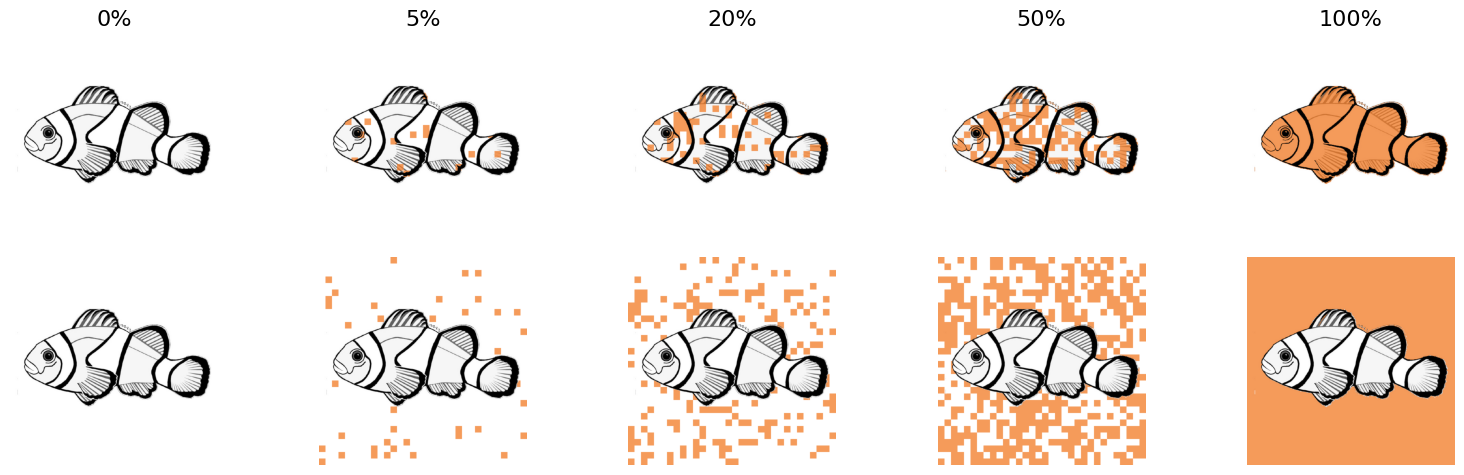

In [9]:
plot_object_fg_vs_bg(
    df=full_prior_df,
    image_root=DATA,
    object_name="anemone fish",
    #title="Anemone Fish - Canonical Prior Coloring"
)

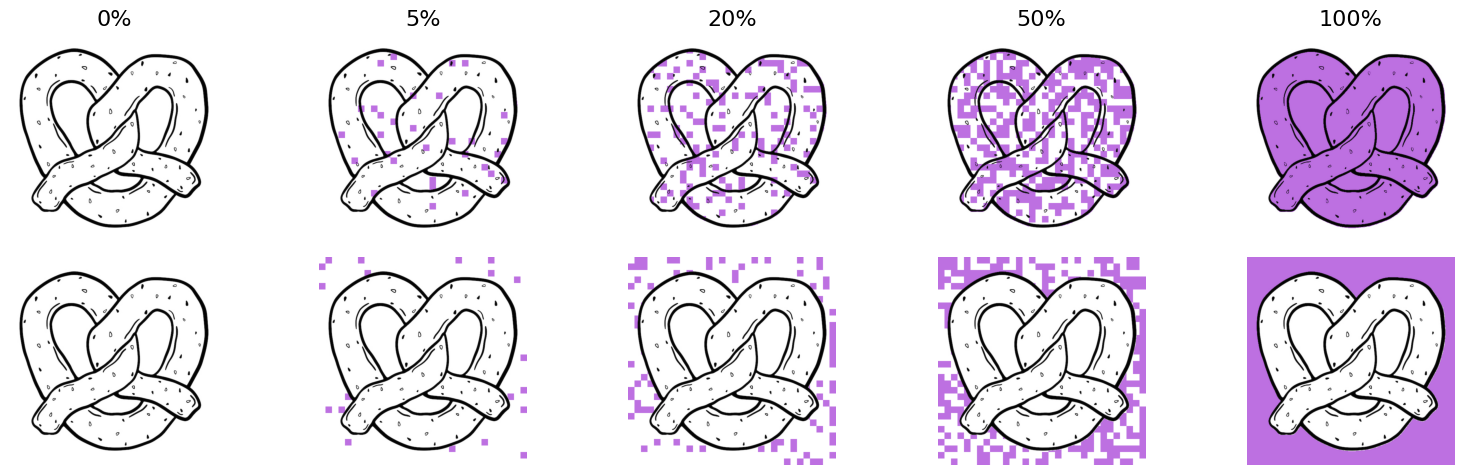

In [10]:
plot_object_fg_vs_bg(
    df=full_counterfact_df,
    image_root=DATA,
    object_name="pretzel",
    #title="Pretzel - Counterfactual Coloring"
)

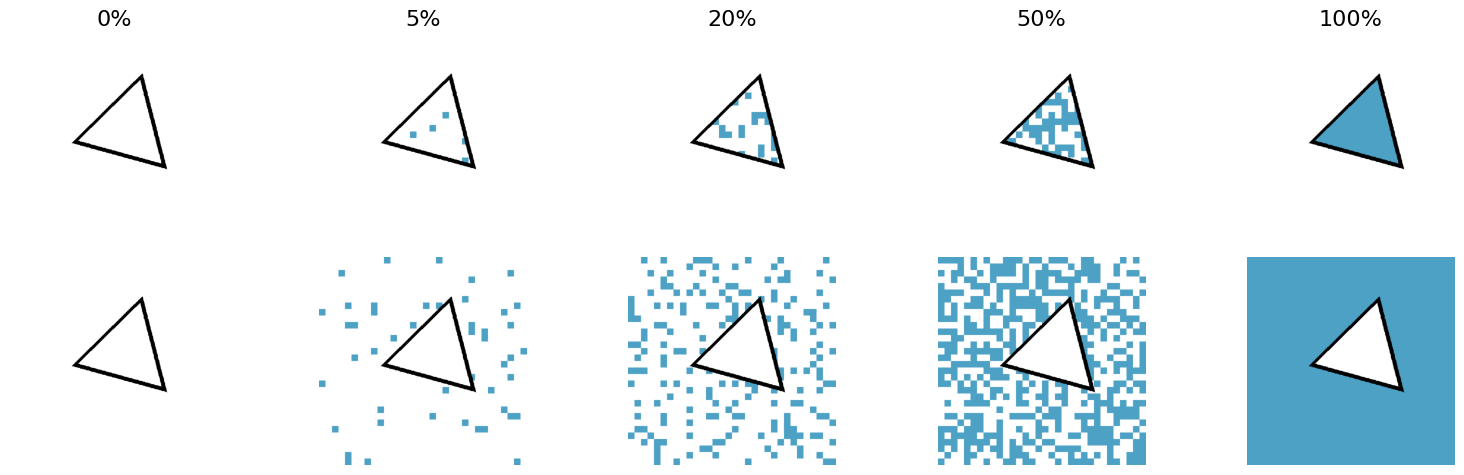

In [11]:
plot_object_fg_vs_bg(
    df=full_shape_df,
    image_root=DATA,
    object_name="triangle",
    #title="Triangle - Shape Dataset"
)

In [ ]:
full_counterfact_df.object.unique()

array(['Band Aid', 'Chesapeake Bay retriever', 'Christmas stocking',
       'Doberman', 'French horn', 'Irish setter', 'Komodo dragon',
       'Loafer', 'Maltese dog', 'Norwegian elkhound',
       'Old English sheepdog', 'Pomeranian', 'Rottweiler',
       'Sealyham terrier', 'acorn', 'acoustic guitar', 'airliner',
       'alligator', 'ambulance', 'american football', 'anemone fish',
       'ant', 'apple', 'armadillo', 'artichoke', 'asparagus', 'axolotl',
       'baseball', 'basketball', 'bat (animal)', 'bath towel', 'bathtub',
       'bear', 'beetle', 'beets', 'binoculars', 'bison', 'blackbird',
       'bluejay', 'boat', 'brick', 'broccoli', 'buffalo', 'bullfrog',
       'bus', 'butternut squash', 'cabbage butterfly', 'camel', 'canary',
       'cannon', 'car wheel', 'carrot', 'celery', 'cello', 'cheese',
       'cheeseburger', 'cheetah', 'chimpanzee', 'chinese lantern',
       'cloud', 'cockroach', 'coho', 'corn', 'cougar', 'cow', 'crab',
       'crane (machine)', 'curly-coated retriev